# Deep Learning for American Put Option Pricing
## Theoretical Foundations and Numerical Motivation

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `01_option_pricing_foundations.ipynb`

This notebook establishes the theoretical and empirical motivation for the project. It combines academic discussion with small executable demonstrations. The main production logic remains in `src/`, while the notebook imports those functions, visualizes their behaviour, and interprets the results. The whole structure of the project would mostly follow this pattern.

> This project is an academic exercise. It does not constitute investment advice, a trading recommendation, or a production-ready valuation framework.

## Abstract

American options are more difficult to value than European options because they can be exercised before maturity. This creates an additional decision at every possible exercise date: whether it is better to exercise immediately or continue holding the option. In most cases, this means that no simple closed-form pricing formula is available and a numerical method is required.

This project examines whether deep learning can provide a fast and reliable approximation of American put prices and early-exercise decisions. The training data were generated with a high-resolution Cox–Ross–Rubinstein tree and validated against `QuantLib`. Several neural-network approaches were compared, including a direct pricing model, a financially structured model that learns only the early-exercise premium, a multi-task model combining pricing and exercise classification, and a neural Longstaff–Schwartz approach.

The results show that deep learning can approximate American put values with high accuracy and very fast inference, especially when the model includes known financial structure. The best-performing model predicted a non-negative residual above the relevant financial price floor and achieved substantially lower error than the direct neural baseline while eliminating lower-bound violations. At the same time, more complex multi-task and neural Longstaff–Schwartz models did not automatically perform better, and all models showed weaker results outside their training domain.

The project therefore does not claim that deep learning produces a better theoretical price than established numerical methods. Its practical value is as a fast surrogate for repeated valuations, such as portfolio analysis, stress testing and large scenario calculations, provided that, such as portfolio analysis, stress testing and large the model is used within a clearly defined and monitored parameter range.


**Keywords:** American put option; deep learning; early-exercise premium; optimal stopping; binomial tree; Black–Scholes; Least-Squares Monte Carlo; surrogate pricing

# 1. Environment and project structure

The notebook is expected to live under `notebooks/`, while reusable code will live under `src/`. The setup cell adds the project root to the Python path. The first numerical demonstrations run independently; later cells require `src/pricing/black_scholes.py` and `src/pricing/binomial_tree.py`.

In [1]:
#Import your libraries here

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torchinfo import summary as torchinfo_summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Project root:       {PROJECT_ROOT}")

Notebook directory: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\notebooks
Project root:       D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing


In [2]:
#Import your modules here

from src.pricing.black_scholes import (
    black_scholes_call_price,
    black_scholes_put_price,
)

from src.pricing.binomial_tree import crr_option_price

from src.models.direct_pricer import (
    DirectAmericanPutMLP,
    DirectMLPConfig,
)
from src.models.premium_pricer import (
    PremiumAmericanPutMLP,
    PremiumMLPConfig,
)
from src.models.multitask_pricer import (
    ExerciseClassifierConfig,
    ExerciseClassifierMLP,
    MultiTaskAmericanPutMLP,
    MultiTaskMLPConfig,
)
from src.models.neural_longstaff_schwartz import (
    ContinuationNetworkConfig,
    ContinuationValueNetwork,
)
from src.models.integrated_multihead_pricer import (
    IntegratedAmericanPutMultiHeadMLP,
    IntegratedMultiHeadConfig,
)



# 2. Motivation and continuity with previous work

This project continues my earlier SoftUni *Math for Developers* final project, [Mathematical Foundations of Portfolio Optimization and Hedging](https://github.com/Kamend1/math_for_developers_final_project). That work connected portfolio optimization, Black–Scholes European-style options pricing, protective puts, Greeks, convexity, and embedded optionality.

The earlier project concentrated on European-style valuation, where Black–Scholes provides a closed-form solution under restrictive assumptions. The present project moves to a harder problem: an American option may be exercised before maturity, so valuation includes a decision problem - additional optionality built in the option contract.

While in the Data Science and Machine Learning courses' final projects I looked at attempting work of my own design, developing certain ideas that I had long sought to exploit, in this course I could not really find a novel topic, which has not been thoroughly researched for the application of deep learning methods.

I did consider returning to the concepts of algorithmic trading, which, starting with my [*Data Science* final project](https://github.com/Kamend1/math_for_developers_final_project), were intended to be the main topic of research for the whole program. However, at the moment I have paused this direction as I still believe noise dominates daily stock returns, which is quite problematic. I will continue to explore in the future the possible applications of AI and deep learning, and make experiments with models like [Kronos](https://huggingface.co/NeoQuasar/Kronos-base). I also considered adding a deep learning layer to the [credit clustering tool](https://github.com/Kamend1/corporate_credit_clustering_tool), which was my SoftUni ML course final project; however, the limited number of observations stopped me for the moment for additional consideration.

Yet, I wanted the course and program final project to remain in the financial domain. Looking for ideas, I surprisingly identified that for several years now, the application of deep learning in option pricing has been repeatedly researched. As demonstrated in my math course's project, option prices are indeed complex non-linear dependencies on various factors and attributes of the option contract; yet I did not see direct possibilities to apply deep learning to the subject before finding numerous research articles on the topic. I have selected several of the most interesting articles I have come across in my own research, and I will attempt to reproduce various approaches and comment on the findings from my own perspective. I hope that I will be able to provide viable business applications, test valid hypotheses, and provide scientifically sound answers without fallacies in the research.

Training a neural network merely to reproduce Black–Scholes pricing model would demonstrate function approximation but create limited practical value because the analytical formula already exists and is computationally cheap. Elbayed and Qadi El Idrissi (2025) provide a useful baseline by showing that a dense network can approximate synthetic European put prices very successfully. This is why I focused on American-style options for the project work. For a non-dividend-paying stock, early exercise of an American call is generally considered to be never optimal because it sacrifices the option’s remaining time value without providing an economic benefit. Its value is therefore the same as a European call, which is why this project focused on American puts, where early exercise can be optimal. This is why I limited the scope of the current state of this project to American-style put options only, in order to contain the scope and the additional complexity of the researched questions.

I saw the potential of stronger application lying in the work to approximate a numerical pricing procedure that becomes expensive when repeated across large portfolios, scenario grids, or risk calculations, and there building deep learning models can have a visible advantage. I will use ideas from the models described in the papers I have researched, explore the results, and comment on the findings as they come out. 

# 3. Representative contract

In the next several paragraphs and code cells, I will make an introduction to the subject of American put options. A slightly in-the-money American put is useful for the first demonstration because immediate exercise may become economically relevant. The values below are controlled model parameters, not market observations.

In [3]:
example_option = {
    "spot": 90.0,
    "strike": 100.0,
    "time_to_maturity": 1.0,
    "risk_free_rate": 0.05,
    "dividend_yield": 0.02,
    "volatility": 0.25,
}

pd.Series(example_option, name="Value").to_frame()

,Value
spot,90.00
strike,100.00
time_to_maturity,1.00
risk_free_rate,0.05
dividend_yield,0.02
volatility,0.25


# 4. Intrinsic value and immediate exercise

For a put option,

$$
I(S)=\max(K-S,0).
$$

This is the value available from immediate exercise and therefore a lower bound for an American put:

$$
V_A\geq\max(K-S,0).
$$

Here, $K$ is the option’s strike price, $S$ is the current price of the underlying asset, and $I(S)$ is the option’s intrinsic value at price $S$. The expression $max(K−S,0)$ means that the put has positive intrinsic value only when the strike price is above the current asset price.

In the second inequality, $V_A$ denotes the value of the American put option. Since the holder may exercise immediately, the option cannot be worth less than its intrinsic value

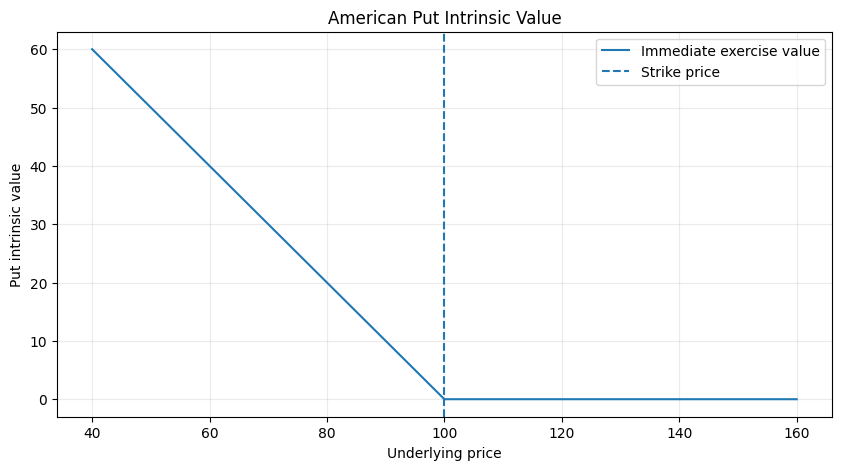

In [4]:
spot_grid = np.linspace(40.0, 160.0, 500)
strike = example_option["strike"]
put_intrinsic = np.maximum(strike - spot_grid, 0.0)

plt.figure(figsize=(10, 5))
plt.plot(spot_grid, put_intrinsic, label="Immediate exercise value")
plt.axvline(strike, linestyle="--", label="Strike price")
plt.xlabel("Underlying price")
plt.ylabel("Put intrinsic value")
plt.title("American Put Intrinsic Value")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

The payoff is linear below the strike and zero above it. It is not the complete option value because it ignores the value of waiting and retaining exposure to future uncertainty.

# 5. European Black–Scholes benchmark

The famous Black-Scholes equation is the main pillar of option valuation applied to European-style option contracts, which do not have early-exercise optionality. With continuous dividend yield,

$$
P_E=Ke^{-rT}N(-d_2)-Se^{-qT}N(-d_1),
$$

where

$$
d_1=\frac{\ln(S/K)+(r-q+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
\qquad d_2=d_1-\sigma\sqrt{T}.
$$

The European value is a benchmark, a lower bound for the corresponding American option, and the known component of the proposed early-exercise-premium model.

In these expressions $P_E$ is the value of the European put option, $K$ is the strike price, $S$ is the current price of the underlying asset, $r$ is the continuously compounded risk-free interest rate, $q$ is the continuous dividend yield, $T$ is the time remaining to maturity, and $\sigma$ is the volatility of the underlying asset’s returns. The terms $d_1$ and $d_2$ are intermediate quantities used in the Black–Scholes formula, $N(\cdot)$ is the cumulative distribution function of the standard normal distribution, $\ln(\cdot)$ is the natural logarithm, and $e$ is the base of the natural logarithm.

In [5]:
european_put = black_scholes_put_price(**example_option)
intrinsic_value = max(example_option["strike"] - example_option["spot"], 0.0)

print(f"European Black–Scholes put: {european_put:.6f}")
print(f"Immediate exercise value:  {intrinsic_value:.6f}")

European Black–Scholes put: 12.980402
Immediate exercise value:  10.000000


# 6. American valuation as optimal stopping

At each node, the holder compares intrinsic value with continuation value:

$$
V_A(S_t,t)=\max\left(I(S_t),C(S_t,t)\right).
$$

Here, $V_A(S_t,t)$ is the value of the American put at time $t$ when the underlying asset price is $S_t$, $I(S_t)$ is the value obtained from immediate exercise, and $C(S_t,t)$ is the discounted expected value of continuing to hold the option. The holder exercises when $I(S_t)$ is greater than or equal to $C(S_t,t)$; otherwise, the option is continued.

The Cox–Ross–Rubinstein (CRR) tree implements this comparison recursively by backward induction (Cox, Ross, and Rubinstein, 1979).

In [6]:
american_put = crr_option_price(
    **example_option,
    steps=1_000,
    option_type="put",
    exercise_style="american",
)

european_tree_put = crr_option_price(
    **example_option,
    steps=1_000,
    option_type="put",
    exercise_style="european",
)

early_exercise_premium = american_put - european_put

pd.DataFrame(
    {
        "Valuation": [
            "Immediate exercise",
            "European Black–Scholes",
            "European CRR tree",
            "American CRR tree",
            "Early-exercise premium",
        ],
        "Value": [
            intrinsic_value,
            european_put,
            european_tree_put,
            american_put,
            early_exercise_premium,
        ],
    }
)

,Valuation,Value
0,Immediate exercise,10.000000
1,European Black–Scholes,12.980402
2,European CRR tree,12.981868
3,American CRR tree,13.660600
4,Early-exercise premium,0.680198


The early-exercise premium is

$$
EEP=V_A-V_E.
$$

Because the American contract includes all exercise rights available under the European contract,

$$
V_A\geq V_E\quad\Rightarrow\quad EEP\geq0.
$$

I will attempt to demonstrate and reproduce ideas that this motivates the main neural architecture:

$$
\widehat V_A=V_{BS}+\operatorname{Softplus}(g_\theta(x)).
$$

# 7. Price functions across moneyness

The next experiment compares intrinsic, European, and American values across a spot-price grid while keeping the other parameters fixed. The vertical difference between the American and European curves is the early-exercise premium.

In [7]:
def price_across_spot_grid(
    spot_values: np.ndarray,
    *,
    strike: float,
    time_to_maturity: float,
    risk_free_rate: float,
    dividend_yield: float,
    volatility: float,
    steps: int = 500,
) -> pd.DataFrame:
    rows = []

    for spot in spot_values:
        common = {
            "spot": float(spot),
            "strike": strike,
            "time_to_maturity": time_to_maturity,
            "risk_free_rate": risk_free_rate,
            "dividend_yield": dividend_yield,
            "volatility": volatility,
        }

        european = black_scholes_put_price(**common)
        american = crr_option_price(
            **common,
            steps=steps,
            option_type="put",
            exercise_style="american",
        )

        rows.append(
            {
                "spot": float(spot),
                "intrinsic": max(strike - spot, 0.0),
                "european_put": european,
                "american_put": american,
                "early_exercise_premium": american - european,
            }
        )

    return pd.DataFrame(rows)


price_grid = price_across_spot_grid(
    np.linspace(50.0, 150.0, 101),
    strike=example_option["strike"],
    time_to_maturity=example_option["time_to_maturity"],
    risk_free_rate=example_option["risk_free_rate"],
    dividend_yield=example_option["dividend_yield"],
    volatility=example_option["volatility"],
)

price_grid.head()

,spot,intrinsic,european_put,american_put,early_exercise_premium
0,50.0,50.0,46.133980,50.0,3.866020
1,51.0,49.0,45.160092,49.0,3.839908
2,52.0,48.0,44.187737,48.0,3.812263
3,53.0,47.0,43.217195,47.0,3.782805
4,54.0,46.0,42.248779,46.0,3.751221


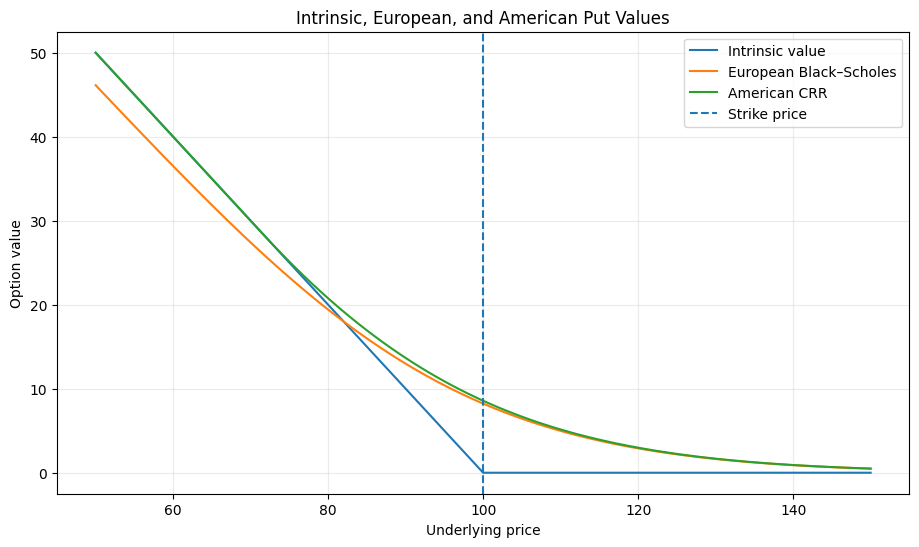

In [8]:
plt.figure(figsize=(11, 6))
plt.plot(price_grid["spot"], price_grid["intrinsic"], label="Intrinsic value")
plt.plot(price_grid["spot"], price_grid["european_put"], label="European Black–Scholes")
plt.plot(price_grid["spot"], price_grid["american_put"], label="American CRR")
plt.axvline(example_option["strike"], linestyle="--", label="Strike price")
plt.xlabel("Underlying price")
plt.ylabel("Option value")
plt.title("Intrinsic, European, and American Put Values")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

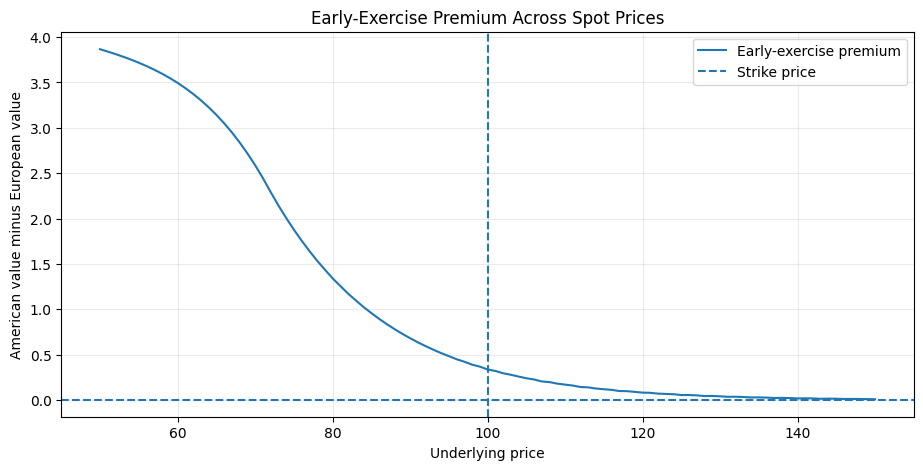

In [9]:
plt.figure(figsize=(11, 5))
plt.plot(price_grid["spot"], price_grid["early_exercise_premium"], label="Early-exercise premium")
plt.axhline(0.0, linestyle="--")
plt.axvline(example_option["strike"], linestyle="--", label="Strike price")
plt.xlabel("Underlying price")
plt.ylabel("American value minus European value")
plt.title("Early-Exercise Premium Across Spot Prices")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

The largest modeling difficulty is expected near the exercise boundary, where the optimal decision changes from continuation to immediate exercise. Aggregate error metrics alone may hide failures in this economically important region.

# 8. Visible financial sanity checks

The formal tests live under `tests/`, but the notebook displays the central checks for the representative calculation.

In [10]:
sanity_checks = pd.Series(
    {
        "American value is non-negative": american_put >= 0.0,
        "American value >= intrinsic value": american_put >= intrinsic_value,
        "American value >= European value": american_put >= european_put,
        "Early-exercise premium is non-negative": early_exercise_premium >= 0.0,
        "European CRR is close to Black–Scholes": np.isclose(
            european_tree_put,
            european_put,
            atol=0.02,
        ),
    },
    name="Passed",
)

sanity_checks.to_frame()

,Passed
American value is non-negative,True
American value >= intrinsic value,True
American value >= European value,True
Early-exercise premium is non-negative,True
European CRR is close to Black–Scholes,True


In [11]:
assert sanity_checks.all(), "At least one financial sanity check failed."

# 9. Literature review and model positioning

## Direct supervised pricing

Ke and Yang (2019) compare a multi-layer perceptron (MLP) and long short-term memory network (LSTM) architectures on historical option data. Their strongest model predicts bid and ask values separately, while their LSTM does not outperform the MLP alternatives. Elbayed and Qadi El Idrissi (2025) demonstrate that a dense network can approximate European put prices generated from Black–Scholes. These studies support a transparent feed-forward baseline but do not resolve the American optimal-stopping problem.

## Sequential models

Pimentel et al. (2026) use five-day SPX European call sequences and a rolling-window design. Their LSTM outperforms Black–Scholes, Heston, and MLP benchmarks at an aggregate level, particularly for longer maturities. Zouaoui and Naas (2023) discuss LSTM and recurrent neural network (GRU) approaches while emphasizing overfitting, data quality, computational cost, and interpretability.

These findings support recurrent architectures when inputs are genuinely sequential. 

For this project, I will generate a synthetic dataset that will serve as the foundation for the experiments that follow. Because the core dataset contains static pricing parameters rather than time sequences, I will not use an LSTM simply to make the model appear more sophisticated.

## American options and richer state representations

Pu (2021) compares supervised neural pricing with neural partial differential equation (PDE) methods and documents material out-of-domain deterioration. Ding, Lu, and Cheung (2025) compress implied-volatility surfaces with a variational autoencoder and use the latent variables to price QuantLib-generated American puts and Asian options. Their work provides a credible future extension, but the core project begins with constant volatility to isolate the early-exercise problem.

# 10. Research goals and questions

The purpose of this project is not simply to show that a neural network can reproduce option prices. That has already been demonstrated many times and, by itself, would add limited practical value. The more relevant question is whether deep learning can approximate a computationally expensive American option pricing procedure well enough to create a real advantage when valuations must be repeated across large portfolios, scenario grids, stress tests, or risk calculations.

The central question of the project is therefore:

> Can a financially structured neural network approximate American put prices, the early-exercise premium, and the exercise decision with sufficient accuracy and financial consistency, while reducing the time required for repeated valuations compared with a numerical pricing method?

The project addresses this through the following research questions:

**RQ1.** Can a conventional multilayer perceptron approximate high-resolution American put prices within a clearly defined parameter range?

**RQ2.** Does learning only the early-exercise premium, rather than the full option price, improve pricing accuracy or training efficiency?

**RQ3.** Can known financial constraints reduce or eliminate economically impossible predictions?

**RQ4.** Can a multi-task model learn both the option price and the exercise-versus-continuation decision, and does this improve either task?

**RQ5.** How stable are the models across different combinations of moneyness, maturity, volatility, interest rates, and dividend yields?

**RQ6.** How materially does model performance deteriorate when the inputs move outside the range used for training?

**RQ7.** Does neural-network inference provide a meaningful computational advantage over repeated numerical valuation, and at what valuation scale does that advantage become practically relevant?


# 11. Predefined hypotheses

The following hypotheses were defined before the final model evaluation. They are intended to test not only whether neural networks can approximate American put prices, but also whether the chosen model structures improve financial consistency and create a practical computational advantage.

### H1 — Direct approximation

A direct MLP will outperform the European Black–Scholes proxy when approximating in-domain American put prices.

### H2 — Premium decomposition

A model trained to predict the early-exercise premium will achieve lower pricing error than a model trained to predict the complete American option value directly.

### H3 — Financial constraints

A financially constrained premium model will produce fewer non-negativity and lower-bound violations than unconstrained neural pricing models.

### H4 — Multi-task exercise learning

Joint pricing and exercise classification will improve exercise-boundary accuracy relative to a standalone exercise classifier.

### H5 — Computational acceleration

After training, batched neural inference will materially reduce the marginal time required for repeated valuations compared with high-resolution numerical pricing.

### H6 — Out-of-domain (OOD) deterioration

Neural pricing models will show materially higher aggregate error on parameter regions that were excluded from the training domain.


# 12. Scope and methodology

## Core scope

- American put options;
- constant volatility, rates, and continuous dividend yield;
- synthetic labels from a validated numerical engine;
- feed-forward neural networks;
- early-exercise-premium prediction;
- exercise-boundary analysis;
- in-domain and out-of-domain tests.

## Input representation

$$
x=[\log(S/K),T,r,q,\sigma],
\qquad y=V_A/K.
$$

Here, $x$ is the vector of input features used by the model, $\log(S/K)$ is the logarithmic moneyness of the option, $S$ is the current price of the underlying asset, $K$ is the strike price, $T$ is the time remaining to maturity, $r$ is the continuously compounded risk-free interest rate, $q$ is the continuous dividend yield, and $\sigma$ is the volatility of the underlying asset’s returns. The target $y$ is the American put value normalized by the strike price, where $V_A$ is the American put price.

## Model architecture roadmap

The cells below instantiate untrained CPU copies of the neural architectures used later in the project. They are included here to make the full modeling path visible before training begins. The summaries show structure and parameter counts only; they do not load data, fit weights, or influence the empirical results.

In [12]:
MODEL_SUMMARY_DEVICE = "cpu"
MODEL_INPUT_SIZE = (1, 5)
MODEL_SUMMARY_COLUMNS = (
    "input_size",
    "output_size",
    "num_params",
    "trainable",
)

torch.manual_seed(42)
print("Architecture summaries will run on CPU with one five-feature observation.")

Architecture summaries will run on CPU with one five-feature observation.


### 12.1 European Black–Scholes proxy — benchmark used from Notebook 04 onward

Black–Scholes is an analytical pricing formula, not a PyTorch model, so there is no neural-network class or `torchinfo` summary to display. It remains essential because it provides the European put benchmark and the known price component used by the residual models. The direct neural model must improve materially on this proxy before it adds practical value.

### 12.2 Direct multilayer perceptron — Notebook 04

The direct model receives the five normalized option-state variables and predicts the complete normalized American put value. It uses four dense hidden layers with SiLU activations, batch normalization after the first two layers, and a final Softplus output.

This is deliberately a strong but conventional baseline. It has enough capacity to learn a smooth nonlinear pricing surface without introducing specialised financial structure. Softplus prevents negative prices, but the model is still allowed to violate the European and intrinsic-value lower bounds. Those weaknesses remain visible for the later models to address.

In [13]:
direct_model_overview = DirectAmericanPutMLP(
    DirectMLPConfig()
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    direct_model_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
DirectAmericanPutMLP                     [1, 5]                    [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 128]                  768                       True
│    └─BatchNorm1d: 2-2                  [1, 128]                  [1, 128]                  256                       True
│    └─SiLU: 2-3                         [1, 128]                  [1, 128]                  --                        --
│    └─Linear: 2-4                       [1, 128]                  [1, 128]                  16,512                    True
│    └─BatchNorm1d: 2-5                  [1, 128]                  [1, 128]                  256                       True
│    

### Why this architecture was selected

The direct MLP is intended to provide a clear and reasonably strong baseline for Notebook 04. The input contains only five static pricing variables, so a fully connected network is the natural starting point. There is no time sequence, image structure, or other relationship that would justify using an LSTM, convolutional network, or attention mechanism at this stage.

The model receives the five normalized pricing inputs and produces one value: the predicted American put price divided by the strike price. The network contains four hidden linear layers with widths of 128, 128, 64, and 32 neurons. This gives the model enough capacity to learn the nonlinear interactions between moneyness, maturity, interest rates, dividend yield, and volatility without making the architecture unnecessarily large.

The first layer expands the five inputs into 128 hidden features. This allows the model to construct a much richer representation than the original five variables. The second 128-neuron layer keeps the same width and gives the network additional capacity to refine interactions between the pricing factors before information starts to be compressed.

The following layers reduce the width from 128 to 64 and then to 32 neurons. This funnel-shaped structure gradually concentrates the learned information into a smaller representation before producing the final price. An immediate reduction from five inputs to one output would be too restrictive, while keeping every layer equally wide would add parameters without an obvious benefit for such a low-dimensional problem.

`BatchNorm1d` is applied after the first two linear layers. Even though the input variables are standardized before training, the distributions of the hidden activations can still change as the network weights are updated. Batch normalization helps keep these internal values on a more stable scale, which can improve optimization and reduce sensitivity to the initial parameter values. It is used only in the two widest layers because these layers perform most of the feature construction. Adding normalization after every narrower layer would increase complexity without necessarily improving this relatively small network.

The hidden layers use the `SiLU` activation function:

$$
\operatorname{SiLU}(z)=z\cdot \operatorname{sigmoid}(z).
$$

`SiLU` is smooth and differentiable across its full range. This is useful for option pricing because the target is a continuous pricing surface rather than a set of discrete classes. Unlike `ReLU`, `SiLU` does not introduce a sharp break at zero and still allows small negative hidden activations to contribute to the model. This supports smoother gradients and a smoother approximation of the pricing function.

No dropout is included in this baseline architecture. The model is relatively small, while the synthetic training dataset is large. Under these conditions, aggressive regularization could reduce the network’s ability to approximate the pricing surface accurately. Overfitting is instead monitored through the validation loss and early stopping during training.

The final linear layer reduces the 32 hidden features to one scalar prediction. A `Softplus` activation is applied to the output:

$$
\operatorname{Softplus}(z)=\log(1+e^z).
$$

An option price cannot be negative, so an unrestricted linear output would allow financially impossible predictions. `Softplus` guarantees a positive output while remaining smooth and trainable. It is preferred here to simply clipping negative predictions after training because the non-negativity requirement becomes part of the model itself.

The output activation only enforces non-negativity. It does not guarantee that the prediction remains above the intrinsic value or the corresponding European option value. This is intentional: the direct MLP is the generic baseline against which the later financially constrained models are compared.

The complete network contains 28,161 trainable parameters. This is small enough to train and evaluate efficiently, but large enough to represent a complex nonlinear pricing relationship. The architecture therefore provides a practical balance between approximation capacity, computational cost, and interpretability. It is not presented as the only possible design, but as a strong baseline from which the value of premium decomposition, financial constraints, and multi-task learning can be measured.

### 12.3 Early-exercise-premium multilayer perceptron — Notebook 05

The premium model keeps the same hidden-layer capacity as the direct model, but changes the learning target. Instead of relearning the complete option value, it predicts the residual above the European Black–Scholes price.

The first version uses a linear output so the experiment can show whether unconstrained residual learning produces negative premiums. Keeping the backbone unchanged is important: any improvement should come from the target decomposition, not from giving this model more capacity.

In [14]:
premium_model_overview = PremiumAmericanPutMLP(
    PremiumMLPConfig(
        output_activation="linear",
        residual_base="european",
    )
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    premium_model_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
PremiumAmericanPutMLP                    [1, 5]                    [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 128]                  768                       True
│    └─BatchNorm1d: 2-2                  [1, 128]                  [1, 128]                  256                       True
│    └─SiLU: 2-3                         [1, 128]                  [1, 128]                  --                        --
│    └─Linear: 2-4                       [1, 128]                  [1, 128]                  16,512                    True
│    └─BatchNorm1d: 2-5                  [1, 128]                  [1, 128]                  256                       True
│    

### 12.4 Financially constrained residual multilayer perceptron — Notebook 05

The constrained model uses the same feed-forward structure, but predicts a non-negative residual above the financial floor: the larger of the European value and intrinsic value. Softplus makes the learned residual non-negative.

The lower-bound guarantee comes from the combination of the model output and the reconstruction rule, not from additional hidden layers. This is a controlled design choice: the comparison isolates the value of financial structure rather than confusing it with a larger network.

In [15]:
constrained_premium_model_overview = PremiumAmericanPutMLP(
    PremiumMLPConfig(
        output_activation="softplus",
        residual_base="financial_floor",
    )
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    constrained_premium_model_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
PremiumAmericanPutMLP                    [1, 5]                    [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 128]                  768                       True
│    └─BatchNorm1d: 2-2                  [1, 128]                  [1, 128]                  256                       True
│    └─SiLU: 2-3                         [1, 128]                  [1, 128]                  --                        --
│    └─Linear: 2-4                       [1, 128]                  [1, 128]                  16,512                    True
│    └─BatchNorm1d: 2-5                  [1, 128]                  [1, 128]                  256                       True
│    

Why these two premium architectures were selected

The two models in Notebook 05 use the same hidden backbone so that the comparison remains focused on the treatment of the early-exercise premium rather than on differences in model capacity. Both receive the same five pricing inputs and pass them through four fully connected layers with widths of 128, 128, 64, and 32 neurons. The first two wider layers build nonlinear interactions between the option parameters, while the narrower layers gradually compress this information into a single premium estimate.

The general design was informed by the option-pricing literature, but the exact architecture was not copied from one article. Elbayed and Qadi El Idrissi used three fully connected layers with 128 neurons each and concluded that this provided a reasonable balance between approximation capacity and computational efficiency. Ke and Yang used a larger four-layer MLP and reported that batch normalization improved training, while dropout did not improve their pricing results. Other reviewed work also supports the use of ordinary fully connected MLPs for static option-pricing inputs.

The exact funnel structure of 128, 128, 64, and 32 neurons is therefore a project-specific adaptation rather than a published architecture reproduced directly. It keeps the model compact while retaining enough capacity for the nonlinear pricing relationship. BatchNorm1d is used in the widest layers to stabilize training, and SiLU is used instead of the ReLU or LeakyReLU activations found in the referenced studies because its smooth shape is well suited to approximating a continuous option-pricing surface.

The difference between the two models is entirely in the output. The unconstrained version uses a linear output and allows the predicted premium to take any value. The second version applies Softplus, which guarantees a non-negative premium while remaining smooth and differentiable. This provides a controlled experiment: the shared network structure remains unchanged, while the project tests whether adding a financially justified non-negativity constraint improves pricing accuracy and consistency.

The early-exercise-premium formulation itself is also a project design choice rather than a direct reproduction of the referenced articles. It follows from separating the known European or financial-floor component from the additional value created by the American exercise right.

### 12.5 Exercise-only classifier — Notebook 06

The exercise-only classifier receives the same five option-state variables but predicts one raw exercise logit rather than a price. Its hidden structure mirrors the direct pricing network, which makes it a fair standalone test of whether the current exercise decision is learnable from the static contract state.

The output remains a logit because the training loss applies the sigmoid transformation internally. This is the classification baseline against which the joint price-and-exercise model is assessed.

In [16]:
exercise_classifier_overview = ExerciseClassifierMLP(
    ExerciseClassifierConfig()
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    exercise_classifier_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ExerciseClassifierMLP                    [1, 5]                    [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 128]                  768                       True
│    └─BatchNorm1d: 2-2                  [1, 128]                  [1, 128]                  256                       True
│    └─SiLU: 2-3                         [1, 128]                  [1, 128]                  --                        --
│    └─Linear: 2-4                       [1, 128]                  [1, 128]                  16,512                    True
│    └─BatchNorm1d: 2-5                  [1, 128]                  [1, 128]                  256                       True
│    

### 12.6 Multi-task price and exercise model — Notebook 06

The multi-task model first builds one shared representation through hidden layers of 128, 128, and 64 units. It then separates into a residual-pricing head and an exercise-classification head, each with one additional 32-unit hidden layer.

The shared backbone tests whether price and stopping information are genuinely complementary. The structure is not assumed to be better merely because it has two outputs. Notebook 06 evaluates whether the joint objective improves boundary decisions without damaging price accuracy.

In [17]:
multitask_model_overview = MultiTaskAmericanPutMLP(
    MultiTaskMLPConfig()
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    multitask_model_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MultiTaskAmericanPutMLP                  [1, 5]                    [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 64]                   --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 128]                  768                       True
│    └─BatchNorm1d: 2-2                  [1, 128]                  [1, 128]                  256                       True
│    └─SiLU: 2-3                         [1, 128]                  [1, 128]                  --                        --
│    └─Linear: 2-4                       [1, 128]                  [1, 128]                  16,512                    True
│    └─BatchNorm1d: 2-5                  [1, 128]                  [1, 128]                  256                       True
│    

### 12.7 Neural Longstaff–Schwartz continuation network — Notebook 07

Notebook 07 is different from the static pricing notebooks. It trains one continuation-value network for each eligible exercise date and works backward through simulated risk-neutral paths. The summary below therefore represents one network in that time-indexed policy.

The network is intentionally smaller, with hidden layers of 64, 64, and 32 units. It must be trained repeatedly across exercise dates, so excessive capacity would multiply both runtime and overfitting risk. The final Softplus output reflects the fact that continuation value cannot be negative.

In [18]:
continuation_network_overview = ContinuationValueNetwork(
    ContinuationNetworkConfig()
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    continuation_network_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ContinuationValueNetwork                 [1, 5]                    [1]                       --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 64]                   384                       True
│    └─SiLU: 2-2                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160                     True
│    └─SiLU: 2-4                         [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-5                       [1, 64]                   [1, 32]                   2,080                     True
│    └─

### 12.8 Final integrated static multi-head model — Notebook 08

The final static model combines the strongest ideas from the earlier experiments. A larger shared backbone produces four outputs: a residual above the financial floor, a direct American price, a continuation value, and an exercise logit.

The constrained residual remains the authoritative price. The direct-price head acts as an internal comparison, while the continuation and exercise heads provide two separate views of the stopping decision. The backbone is wider because it must support four related tasks, and modest dropout is added to control the extra capacity. Notebook 08 tests whether this integration creates measurable value rather than simply a more complicated model.

In [19]:
integrated_multihead_model_overview = IntegratedAmericanPutMultiHeadMLP(
    IntegratedMultiHeadConfig()
).to(MODEL_SUMMARY_DEVICE).eval()

torchinfo_summary(
    integrated_multihead_model_overview,
    input_size=MODEL_INPUT_SIZE,
    device=MODEL_SUMMARY_DEVICE,
    mode="eval",
    col_names=MODEL_SUMMARY_COLUMNS,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
IntegratedAmericanPutMultiHeadMLP        [1, 5]                    [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 5]                    [1, 96]                   --                        True
│    └─Linear: 2-1                       [1, 5]                    [1, 192]                  1,152                     True
│    └─BatchNorm1d: 2-2                  [1, 192]                  [1, 192]                  384                       True
│    └─SiLU: 2-3                         [1, 192]                  [1, 192]                  --                        --
│    └─Dropout: 2-4                      [1, 192]                  [1, 192]                  --                        --
│    └─Linear: 2-5                       [1, 192]                  [1, 192]                  37,056                    True
│    └─

## Evaluation

MAE, RMSE, normalized error, median and maximum absolute error, $R^2$, exercise $F1$, financial-constraint violation rates, and inference time. MAPE will not be primary because it is unstable near zero option values.

The model sequence is designed as a controlled progression. Notebook 04 establishes the direct baseline, Notebook 05 tests residual learning and financial constraints, Notebook 06 adds the exercise decision, Notebook 07 moves to path-based continuation learning, and Notebook 08 integrates the strongest static components. Notebook 09 performs the final cross-model evaluation.

# 13. Reproducibility and leakage controls

The data will be split into training, validation, in-domain test, and separate out-of-domain test sets. Entire parameter regions will be excluded from training to test extrapolation honestly. All normalization statistics will be fitted on the training set only.

Reusable logic remains in `src/`. Tests verify benchmark values, put–call parity, tree convergence, American lower bounds, non-dividend American call equivalence, invalid inputs, and deterministic behaviour.

A neural network trained on an incorrect pricing engine will learn the error rather than correct it. Numerical validation is therefore a prerequisite for large-scale data generation.

# 14. Anticipated limitations

- Synthetic labels inherit the assumptions and errors of the generating model.
- Constant volatility does not reproduce market volatility smiles.
- Continuous dividends do not capture discrete corporate dividend events.
- A numerical benchmark is still an approximation.
- Random sampling may underrepresent the exercise boundary.
- Strong interpolation does not imply reliable extrapolation.
- Inference-speed comparisons exclude training and data-generation cost.

# 15. References used in this notebook

Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy, 81*(3), 637–654.

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Ding, L., Lu, E., & Cheung, K. (2025). *Deep learning option pricing with market implied volatility surfaces*. arXiv:2509.05911.

Elbayed, Z., & Qadi El Idrissi, A. (2025). Deep learning in financial modeling: Predicting European put option prices with neural networks. *Algorithms, 18*(3), 161.

Ke, A., & Yang, A. (2019). *Option pricing with deep learning*. CS230, Stanford University.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Merton, R. C. (1973). Theory of rational option pricing. *Bell Journal of Economics and Management Science, 4*(1), 141–183.

Pimentel, R., Risstad, M., Rogde, S., Rygg, E. S., Vinje, J., Westgaard, S., & Wu, C. (2026). Option pricing with deep learning: A long short-term memory approach. *Decisions in Economics and Finance, 49*, 155–186.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

Zouaoui, H., & Naas, M.-N. (2023). Option pricing using deep learning approach based on LSTM-GRU neural networks. *Data Science in Finance and Economics, 3*(3), 267–284.

# 16. Development checkpoint

Notebook 01 now provides both academic foundations and executable numerical motivation. The next implementation step is to complete:

`src/pricing/black_scholes.py`;
`src/pricing/binomial_tree.py`

against the unit-test contracts delivered with this notebook. Notebook 02 will then perform formal convergence analysis, parameter-domain design, data-generation validation, and runtime benchmarking.